In [1]:
# Kerakli kutubxonalarni chaqirib, Telco ma'lumotlarini yuklayapman va TotalCharges'ni raqamga aylantiryapman
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [2]:
# MonthlyCharges va TotalCharges ustunlarining min/max qiymatlarini ko'rib, oralig'idagi katta farqni aniqlayapman
cols = ['MonthlyCharges', 'TotalCharges']
df[cols].describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,64.76,2279.73
std,30.09,2266.79
min,18.25,0.00
25%,35.50,398.55
50%,70.35,1394.55
75%,89.85,3786.60
max,118.75,8684.80


In [3]:
# MinMaxScaler yordamida ikkala ustunni 0 dan 1 gacha oralig'ga siqib qo'yayapman
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
X = df[cols]
X_mm = mm.fit_transform(X)
X_mm_df = pd.DataFrame(X_mm, columns=cols)
X_mm_df.agg(['min', 'max']).round(2)

,MonthlyCharges,TotalCharges
min,0.0,0.0
max,1.0,1.0


In [4]:
# StandardScaler yordamida ustunlarni o'rtacha=0, standart chetlanish=1 bo'ladigan qilib normallashtirayapman
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X_std = std.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=cols)
X_std_df.describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.55,-1.01
25%,-0.97,-0.83
50%,0.19,-0.39
75%,0.83,0.66
max,1.79,2.83


In [5]:
# RobustScaler yordamida median va IQR asosida scaling qilayapman — bu chetki qiymatlarga (outlier) chidamli usul
from sklearn.preprocessing import RobustScaler
rb = RobustScaler()
X_rb = rb.fit_transform(X)
X_rb_df = pd.DataFrame(X_rb, columns=cols)
X_rb_df.describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.10,0.26
std,0.55,0.67
min,-0.96,-0.41
25%,-0.64,-0.29
50%,0.00,0.00
75%,0.36,0.71
max,0.89,2.15


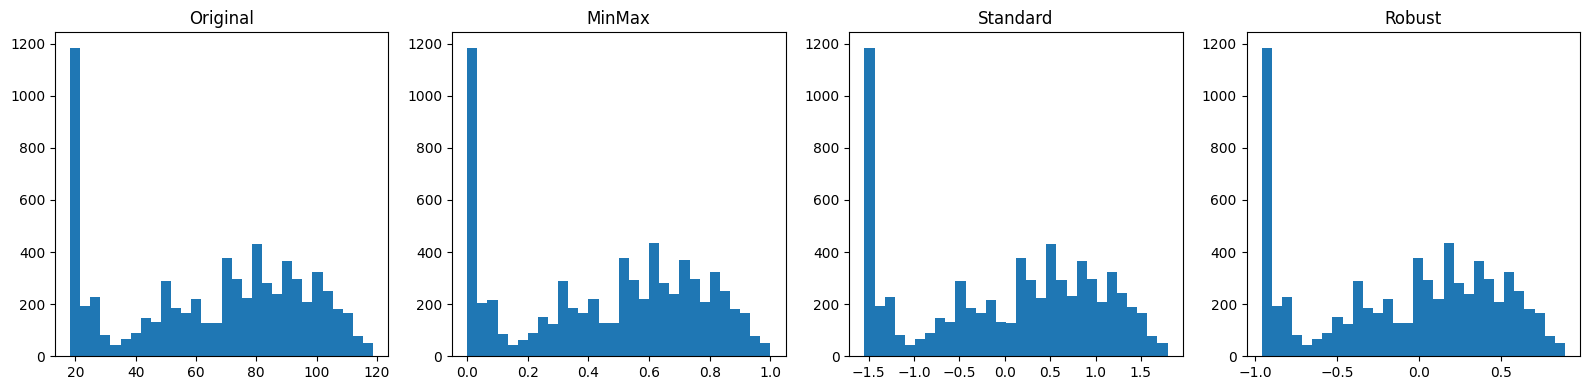

In [6]:
# Original va 3 xil scaling usulidan keyingi MonthlyCharges taqsimotini 4 ta gistogrammada yonma-yon solishtirayapman
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].hist(df['MonthlyCharges'], bins=30); ax[0].set_title('Original')
ax[1].hist(X_mm_df['MonthlyCharges'], bins=30); ax[1].set_title('MinMax')
ax[2].hist(X_std_df['MonthlyCharges'], bins=30); ax[2].set_title('Standard')
ax[3].hist(X_rb_df['MonthlyCharges'], bins=30); ax[3].set_title('Robust')
plt.tight_layout()
plt.show()

In [7]:
# Ma'lumotni avval train/test'ga bo'lib, keyin faqat train'ga fit qilib, test'ga transform qilayapman (data leakage oldini olish uchun)
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Train mean:', X_train_s.mean(axis=0).round(2))
print('Test mean:', X_test_s.mean(axis=0).round(2))

Train mean: [-0.  0.]
Test mean: [-0.02 -0.02]
